In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from isca_emulation_v2.data.utils import load_isca_result_data
from isca_emulation_v2.plotting.plotting_functions import plot_isca_result

## 1. ISCA no SSW

In [2]:
path_no_ssw = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_no_ssw_L60"
file_name ="atmos_daily_interp.nc"

ds_no_ssw = load_isca_result_data(path_no_ssw, file_name)

### 1.1 Time-series of zonal wind 60north, 10hpa

In [ ]:
# ucomp(time, pfull, lat, lon)
u_no_ssw = ds_no_ssw["ucomp"][1000:]
u_no_ssw_60N_p10 = u_no_ssw.sel(pfull=10, lat=60, method="nearest")

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_no_ssw_60N_p10_mean = u_no_ssw_60N_p10.mean(dim="lon")

# A selected longitude (e.g., 0°E):
u_no_ssw_60N_p10_lon0 = u_no_ssw_60N_p10.sel(lon=0, method="nearest")

# Force data into memory, then convert to NumPy
u_no_ssw_60N_p10_mean_np = u_no_ssw_60N_p10_mean.load().to_numpy()
u_no_ssw_60N_p10_lon0_np = u_no_ssw_60N_p10_lon0.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_no_ssw = u_no_ssw_60N_p10["time"].to_numpy()

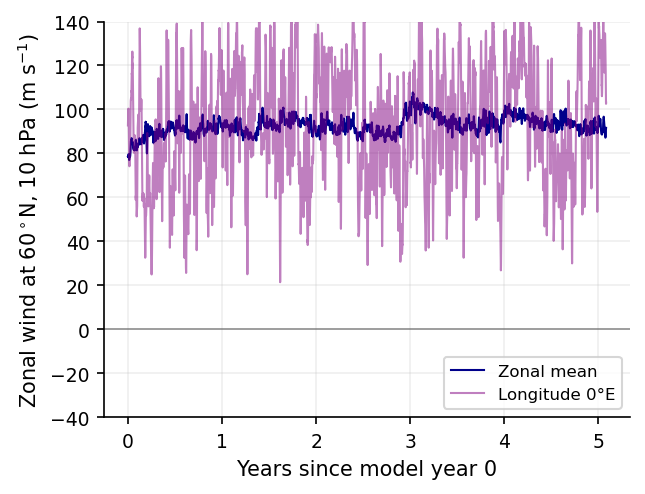

In [5]:
t0 = time_np_no_ssw[0]  # reference time (model year 0)
t_hours = time_np_no_ssw.astype(float)

years_since_0 = (t_hours - t0) / (24 * 365.0)
months_since_0 = (t_hours - t0) / (24 * 30.0)  # approx months

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=150)

# TO ADD blue for poster
# background_rgb = np.array([47, 62, 234]) / 255
# tint = 0.9
# boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
# fig.patch.set_facecolor(boxcolor)   # full figure background
# ax.set_facecolor(boxcolor)          # axes / plotting area background

ax.plot(years_since_0, u_no_ssw_60N_p10_mean_np, lw=1.0, alpha=1, color='darkblue')
ax.plot(years_since_0, u_no_ssw_60N_p10_lon0_np, lw=1.0, alpha=0.5, color='purple')
ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)

ax.set_xlabel("Years since model year 0")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.legend(["Zonal mean", "Longitude 0°E"], fontsize=8, loc="lower right", frameon=True)
#ax.set_title("No SSW", fontsize=10, pad=6)

ax.set_ylim(-40, 140)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### 1.2 Zonal mean presurre / lat 

In [6]:
zonal_mean_pressure_lat_no_ssw = u_no_ssw.mean(dim=["time", "lon"]).load().to_numpy()

pressure_levels_no_ssw = u_no_ssw['pfull'].values
latitude_levels_no_ssw = u_no_ssw['lat'].values

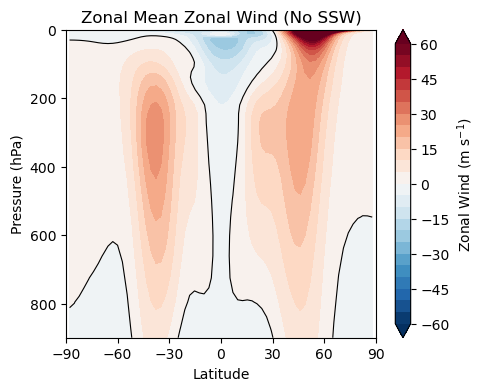

In [7]:
pressure_levels_starting = 12
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)
norm = TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)

cf = ax.contourf(
    latitude_levels_no_ssw,
    pressure_levels_no_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_no_ssw[pressure_levels_starting:],
    levels=levels,
    cmap="RdBu_r",
    norm=norm,
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_no_ssw,
    pressure_levels_no_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_no_ssw[pressure_levels_starting:],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (No SSW)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

## 2. ISCA with SSW

In [3]:
path_with_ssw = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_q6m2y45l800u200_L60"
file_name ="atmos_daily_interp.nc"

ds_with_ssw = load_isca_result_data(path_with_ssw, file_name)

### 2.1 Time-series of zonal wind 60north, 10hpa

In [3]:
# ucomp(time, pfull, lat, lon)
u_with_ssw = ds_with_ssw["ucomp"]

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_with_ssw_60N_p10 = (u_with_ssw.sel(pfull=10, lat=60, method="nearest").mean(dim="lon"))

# Force data into memory, then convert to NumPy
u_with_ssw_60N_p10_np = u_with_ssw_60N_p10.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_with_ssw = u_with_ssw_60N_p10["time"].to_numpy()

In [4]:
# ucomp(time, pfull, lat, lon)
u_with_ssw = ds_with_ssw["ucomp"][1000:]
u_with_ssw_60N_p10 = u_with_ssw.sel(pfull=10, lat=60, method="nearest")

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_with_ssw_60N_p10_mean = u_with_ssw_60N_p10.mean(dim="lon")

# A selected longitude (e.g., 0°E):
u_with_ssw_60N_p10_lon0 = u_with_ssw_60N_p10.sel(lon=0, method="nearest")

# Force data into memory, then convert to NumPy
u_with_ssw_60N_p10_mean_np = u_with_ssw_60N_p10_mean.load().to_numpy()
u_with_ssw_60N_p10_lon0_np = u_with_ssw_60N_p10_lon0.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_with_ssw = u_with_ssw_60N_p10["time"].to_numpy()

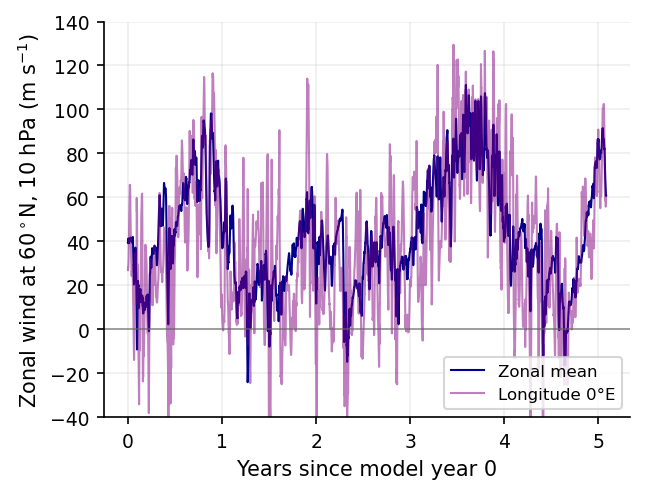

In [5]:
t0 = time_np_with_ssw[0]  # reference time (model year 0)
t_hours = time_np_with_ssw.astype(float)

years_since_0 = (t_hours - t0) / (24 * 365.0)
months_since_0 = (t_hours - t0) / (24 * 30.0)  # approx months

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=150)

# # TO ADD blue for poster
# background_rgb = np.array([47, 62, 234]) / 255
# tint = 0.9
# boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
# fig.patch.set_facecolor(boxcolor)   # full figure background
# ax.set_facecolor(boxcolor)          # axes / plotting area background

ax.plot(years_since_0, u_with_ssw_60N_p10_mean_np, lw=1.0, alpha=1, color='darkblue')
ax.plot(years_since_0, u_with_ssw_60N_p10_lon0_np, lw=1.0, alpha=0.5, color='purple')

ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)
# ax.axvline(years_since_0[400], lw=0.8, color="red", alpha=0.7, ls="--")
# ax.axvline(years_since_0[2100], lw=0.8, color="red", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3001], lw=0.8, color="blue", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3250], lw=0.8, color="blue", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3251], lw=0.8, color="green", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3500], lw=0.8, color="green", alpha=0.7, ls="--")
# ax.axvline(years_since_0[4300], lw=0.8, color="yellow", alpha=0.7, ls="--")
# ax.axvline(years_since_0[5000], lw=0.8, color="yellow", alpha=0.7, ls="--")

ax.set_xlabel("Years since model year 0")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.legend(["Zonal mean", "Longitude 0°E"], fontsize=8, loc="lower right", frameon=True)
#ax.set_title("With SSW", fontsize=10, pad=6)

ax.set_ylim(-40, 140)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)


plt.tight_layout()
plt.show()

### 2.2 Time-series of zonal wind 60north, 10hpa --> identify SSWs

Detected 6 distinct SSW crossings (after filtering).


,SSW_event_date,ssw_event_date_minus10
0,1276,1196
1,4698,4618
2,5387,5307
3,7781,7701
4,13869,13789
5,14533,14453


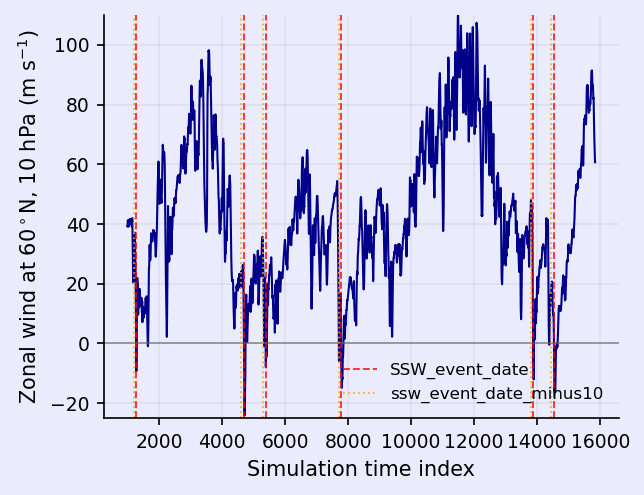

In [4]:
import pandas as pd
from IPython.display import display

# 1) 10 hPa, 60N zonal-mean wind time series (skip early spin-up segment)
steps_per_day = 8  # atmos_daily_interp.nc is 3-hourly
spinup_steps = 1000

u10_60 = (
    ds_with_ssw["ucomp"]
    .isel(time=slice(spinup_steps, None))
    .sel(pfull=10, lat=60, method="nearest")
    .mean("lon")
    .load()
)

# 2) SSW onset candidate: first crossing from >0 to <=0
crossings = ((u10_60.shift(time=1) > 0) & (u10_60 <= 0)).fillna(False)
raw_idx = np.where(crossings.values)[0]

# 3) Keep robust/distinct events
min_neg_days = 2   # must remain negative for at least 2 days after onset
min_sep_days = 30  # minimum separation between accepted events
min_neg_steps = min_neg_days * steps_per_day
min_sep_steps = min_sep_days * steps_per_day

event_idx = []
for i in raw_idx:
    if i + min_neg_steps > u10_60.sizes["time"]:
        continue
    if not bool((u10_60.isel(time=slice(i, i + min_neg_steps)) < 0).all()):
        continue
    if len(event_idx) == 0 or (i - event_idx[-1]) >= min_sep_steps:
        event_idx.append(int(i))

event_idx = np.array(event_idx, dtype=int)

# Convert to full ds_with_ssw time indices (simulation index)
event_idx_full = event_idx + spinup_steps
pre10_idx_full = np.maximum(event_idx_full - 10 * steps_per_day, 0)

ssw_event_summary = pd.DataFrame(
    {
        "SSW_event_date": event_idx_full,
        "ssw_event_date_minus10": pre10_idx_full,
    }
)

print(f"Detected {len(ssw_event_summary)} distinct SSW crossings (after filtering).")
display(ssw_event_summary)

# 4) Same chart + vertical lines for event and event-10d indices
u10_60_np = u10_60.to_numpy()
time_idx = np.arange(spinup_steps, spinup_steps + u10_60.sizes["time"])

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=150)

background_rgb = np.array([47, 62, 234]) / 255
tint = 0.9
boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
fig.patch.set_facecolor(boxcolor)
ax.set_facecolor(boxcolor)

ax.plot(time_idx, u10_60_np, lw=1.0, alpha=1, color="darkblue")
ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)

for j, x in enumerate(event_idx_full):
    ax.axvline(
        x,
        lw=0.9,
        color="red",
        alpha=0.8,
        ls="--",
        label="SSW_event_date" if j == 0 else None,
    )

for j, x in enumerate(pre10_idx_full):
    ax.axvline(
        x,
        lw=0.9,
        color="orange",
        alpha=0.8,
        ls=":",
        label="ssw_event_date_minus10" if j == 0 else None,
    )

ax.set_xlabel("Simulation time index")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.set_ylim(-25, 110)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)
ax.legend(fontsize=8, loc="lower right", frameon=False)

plt.tight_layout()
plt.show()



In [5]:
steps_per_day = 8

n_events = len(ssw_event_summary)
n_steps_analyzed = u10_60.sizes["time"]
n_days_analyzed = n_steps_analyzed / steps_per_day
n_years_analyzed = n_days_analyzed / 360  # 30-day-month calendar

freq_per_100_days = n_events / n_days_analyzed * 100
freq_per_year = n_events / n_years_analyzed

print(f"Events: {n_events}")
print(f"Analyzed length: {n_days_analyzed:.1f} days = {n_years_analyzed:.2f} model years")
print(f"SSW frequency: {freq_per_100_days:.2f} events per 100 days")
print(f"SSW frequency: {freq_per_year:.2f} events per 360-day model year")

Events: 6
Analyzed length: 1855.0 days = 5.15 model years
SSW frequency: 0.32 events per 100 days
SSW frequency: 1.16 events per 360-day model year


### 2.3 Zonal mean lattitude / pressure

In [127]:
## get the data needed
u_with_ssw = ds_with_ssw["ucomp"][1000:]

zonal_mean_pressure_lat_with_ssw = u_with_ssw.mean(dim=["time", "lon"]).load().to_numpy()

pressure_levels_with_ssw = u_with_ssw['pfull'].values
latitude_levels_with_ssw = u_with_ssw['lat'].values

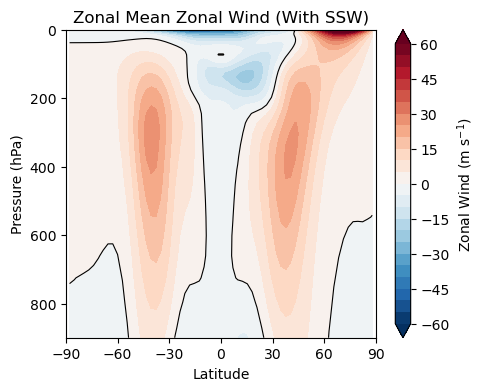

In [141]:
pressure_levels_starting = 12
# Make the plot
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)

cf = ax.contourf(
    latitude_levels_with_ssw,
    pressure_levels_with_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_with_ssw[pressure_levels_starting:],
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_with_ssw,
    pressure_levels_with_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_with_ssw[pressure_levels_starting:],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (With SSW)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

### 2.3 Dripping paint plot proxy

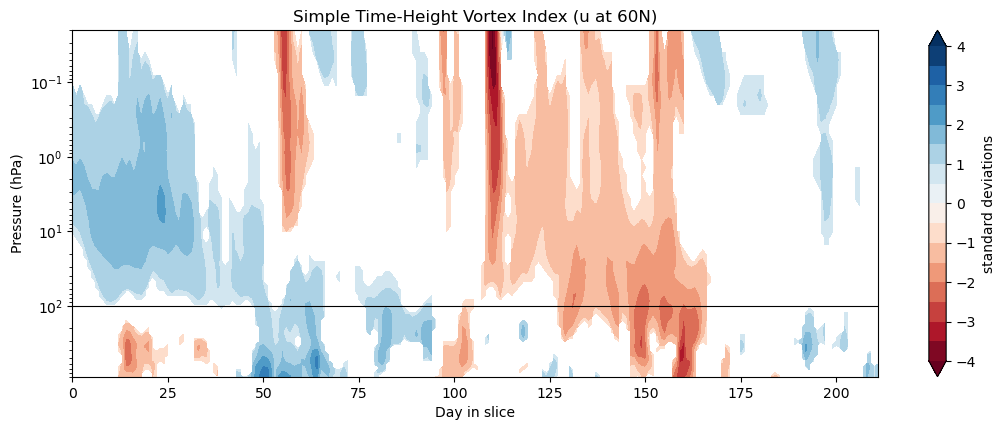

In [57]:
import numpy as np
import matplotlib.pyplot as plt

ds = ds_with_ssw.isel(time=slice(400, 2100))

# 3-hourly -> daily mean (8 steps/day)
ds_day = ds.coarsen(time=8, boundary="trim").mean()

# Simple index matrix: zonal-mean zonal wind at 60N (time, pfull)
I = ds_day["ucomp"].mean("lon").interp(lat=60)

# Standardize each pressure level (nondimensional)
I = (I - I.mean("time")) / I.std("time")

# Match figure style: leave -0.5..0.5 unshaded
I_plot = I.where(np.abs(I) >= 0.8)
levels = np.arange(-4.0, 4.5, 0.5)

fig, ax = plt.subplots(figsize=(13, 4.5))
cf = ax.contourf(
    np.arange(I_plot.sizes["time"]),
    I_plot["pfull"].values,
    I_plot.transpose("pfull", "time").values,
    levels=levels,
    cmap="RdBu",
    extend="both",
)
ax.set_yscale("log")
ax.set_ylim(float(I_plot["pfull"].max()), float(I_plot["pfull"].min()))
ax.axhline(100, color="k", lw=0.8)
ax.set_xlabel("Day in slice")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Simple Time-Height Vortex Index (u at 60N)")
plt.colorbar(cf, ax=ax, label="standard deviations")
plt.show()


## 3. JRA 55 data

In [104]:
path_to_jra = "/home/obola/repositories/isca_emulation_v2/notebooks/data_for_paper/mthm051_jra_55_monthly_av_1958_2016.nc"
ds_jra = xr.open_dataset(path_to_jra)

In [121]:
u_jra = ds_jra["ucomp"].where(ds_jra["month"].isin([12, 1, 2]), drop=True)
u_jra_zonal_mean_pressure_lat_jra = u_jra.mean(dim=["month", "lon"]).load().to_numpy()

pressure_levels_jra = u_jra['pfull_2'].values/100
latitude_levels_jra = u_jra['lat'].values

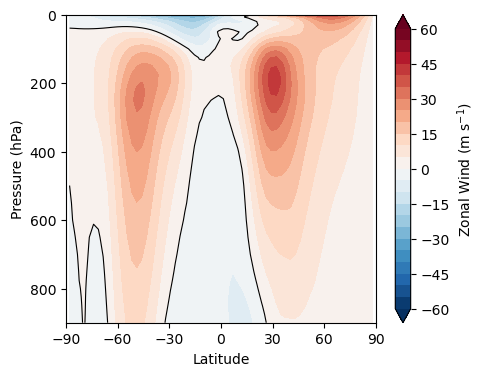

In [ ]:
num_pressure_levels_used = 33
# Make the plot
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)

cf = ax.contourf(
    latitude_levels_jra,
    pressure_levels_jra[:num_pressure_levels_used],
    u_jra_zonal_mean_pressure_lat_jra[:num_pressure_levels_used],
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_jra,
    pressure_levels_jra[:num_pressure_levels_used],
    u_jra_zonal_mean_pressure_lat_jra[:num_pressure_levels_used],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (JRA-55)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

## 4. ISCA figure for paper

In [7]:
path_with_ssw = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_q6m2y45l800u200_L60"
file_name ="atmos_daily_interp.nc"

ds_with_ssw = load_isca_result_data(path_with_ssw, file_name)

In [8]:
ds_with_ssw

<xarray.Dataset> Size: 251GB
Dimensions:        (time: 15840, pfull: 60, lat: 64, lon: 128, lonb: 129,
                    latb: 65)
Coordinates:
  * lon            (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * lonb           (lonb) float64 1kB -1.406 1.406 4.219 ... 353.0 355.8 358.6
  * lat            (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * latb           (latb) float64 520B -90.0 -86.58 -83.76 ... 83.76 86.58 90.0
  * pfull          (pfull) float32 240B 0.02 0.04 0.05 ... 795.4 872.0 900.0
  * time           (time) float64 127kB 1.727e+07 1.727e+07 ... 1.732e+07
Data variables:
    height         (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    slp            (time, lat, lon) float32 519MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    ps             (time, lat, lon) float32 519MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    sphum          (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    zsurf          (time, lat, lon) float32 519MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    ucomp          (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    vcomp          (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    omega          (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    temp           (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    teq            (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    local_heating  (time, pfull, lat, lon) float32 31GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
Attributes:
    filename:   /home/obola/isca_data//Oskar_data_generation_large_run_q6m2y4...
    title:      FMS Model results
    grid_type:  regular
    grid_tile:  N/A
    comment:    pressure level interpolator, version 3.0, precision=double

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def _camera_basis(elev, azim):
    az = np.deg2rad(azim)
    el = np.deg2rad(elev)

    view_dir = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ], dtype=float)
    view_dir /= np.linalg.norm(view_dir)

    world_up = np.array([0.0, 0.0, 1.0], dtype=float)
    right = np.cross(world_up, view_dir)

    if np.linalg.norm(right) < 1e-10:
        world_up = np.array([0.0, 1.0, 0.0], dtype=float)
        right = np.cross(world_up, view_dir)

    right /= np.linalg.norm(right)
    up = np.cross(view_dir, right)
    up /= np.linalg.norm(up)

    return view_dir, right, up


def _get_field_on_sphere(ds, var, time_idx, level):
    da = (
        ds[var]
        .isel(time=time_idx)
        .sel(pfull=level, method="nearest")
        .load()
    )

    da = da.interp(
    lat=np.linspace(float(da.lat.min()), float(da.lat.max()), 181),
    lon=np.linspace(float(da.lon.min()), float(da.lon.max()), 361),
    )

    lat = da["lat"].values
    lon = da["lon"].values
    field = da.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    lon_rad = np.deg2rad(lon2d)
    lat_rad = np.deg2rad(lat2d)

    # unit sphere coordinates
    px = np.cos(lat_rad) * np.cos(lon_rad)
    py = np.cos(lat_rad) * np.sin(lon_rad)
    pz = np.sin(lat_rad)

    return field, px, py, pz


def plot_layered_cutaway_globe(
    ds,
    var="temp",
    time_idx=1000,
    layers=None,
    elev=10,
    azim=90,
    cmap_name="coolwarm",
    figsize=(6, 6),
    dpi=120,
    lim=1.35,
    hole_x=0.18,
    hole_y=0.03,
    light_dir=(0.6, -0.4, 0.7),
    light_strength=0.18,
    rim_strength=0.28,
    rim_sigma=0.05,
    depth_darkening_per_layer=0.10,
    add_wireframe=False,
    wire_stride=4,
    wire_lw=0.35,
    wire_alpha=0.15,
):
    """
    Plot concentric cutaway climate shells.

    layers: list of dicts like
    [
        {"level": 900, "radius": 1.00, "alpha": 1.00, "hole_radius": 0.00},
        {"level": 500, "radius": 1.06, "alpha": 0.65, "hole_radius": 0.34},
        {"level": 100, "radius": 1.12, "alpha": 0.45, "hole_radius": 0.50},
    ]
    """

    if layers is None:
        raise ValueError("Must provide layers configuration")
    # cache data for each layer
    cached = {}
    for layer in layers:
        level = layer["level"]
        cached[level] = _get_field_on_sphere(ds, var, time_idx, level)

    view_dir, right, up = _camera_basis(elev, azim)
    cmap = plt.get_cmap(cmap_name)

    light_dir = np.asarray(light_dir, dtype=float)
    light_dir /= np.linalg.norm(light_dir)

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")

    for i, layer in enumerate(layers):
        level = layer["level"]
        radius = layer["radius"]
        alpha = layer["alpha"]
        hole_radius = layer["hole_radius"]

        field, px, py, pz = cached[level]

        # actual shell coordinates
        x = radius * px
        y = radius * py
        z = radius * pz

        # project sphere onto screen basis to define through-hole
        screen_x = px * right[0] + py * right[1] + pz * right[2]
        screen_y = px * up[0]    + py * up[1]    + pz * up[2]

        if hole_radius > 0:
            opening = (screen_x - hole_x) ** 2 + (screen_y - hole_y) ** 2 < hole_radius ** 2
        else:
            opening = np.zeros_like(field, dtype=bool)

        x_masked = np.where(opening, np.nan, x)
        y_masked = np.where(opening, np.nan, y)
        z_masked = np.where(opening, np.nan, z)

        # separate normalization per pressure level
        layer_vmin = np.nanpercentile(field, 2)
        layer_vmax = np.nanpercentile(field, 98)
        norm = mpl.colors.Normalize(vmin=layer_vmin, vmax=layer_vmax)
        base = cmap(norm(field))

        # 1) fake directional lighting
        lambert = px * light_dir[0] + py * light_dir[1] + pz * light_dir[2]
        lambert = np.clip(lambert, -1.0, 1.0)

        lighting = 1.0 + light_strength * lambert
        lighting = np.clip(lighting, 0.75, 1.20)

        facecolors = base.copy()
        facecolors[..., :3] *= lighting[..., None]

        # 2) dark rim around opening
        if hole_radius > 0:
            dist = np.sqrt((screen_x - hole_x) ** 2 + (screen_y - hole_y) ** 2)
            rim_shadow = np.exp(-((dist - hole_radius) / rim_sigma) ** 2)
            rim_shadow = np.where(dist >= hole_radius, rim_shadow, 0.0)
            facecolors[..., :3] *= (1.0 - rim_strength * rim_shadow[..., None])

        # 3) slightly darken outer/inner shells for depth
        depth_factor = 1.0 - depth_darkening_per_layer * i
        facecolors[..., :3] *= depth_factor

        facecolors[..., :3] = np.clip(facecolors[..., :3], 0, 1)
        # fade back-facing side so shells look thinner
        view_cos = px * view_dir[0] + py * view_dir[1] + pz * view_dir[2]

        # front-facing -> 1.0, back-facing -> reduced alpha
        back_fade = np.where(view_cos >= 0, 1.0, 0.30)

        facecolors[..., -1] = alpha * back_fade
        facecolors[opening, -1] = 0.0

        ax.plot_surface(
            x_masked,
            y_masked,
            z_masked,
            facecolors=facecolors,
            rstride=1,
            cstride=1,
            linewidth=0,
            antialiased=False,
            shade=False,
        )

        if add_wireframe:
            ax.plot_wireframe(
                x_masked,
                y_masked,
                z_masked,
                rstride=wire_stride,
                cstride=wire_stride,
                linewidth=wire_lw,
                alpha=wire_alpha,
            )

    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_axis_off()

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    return fig, ax

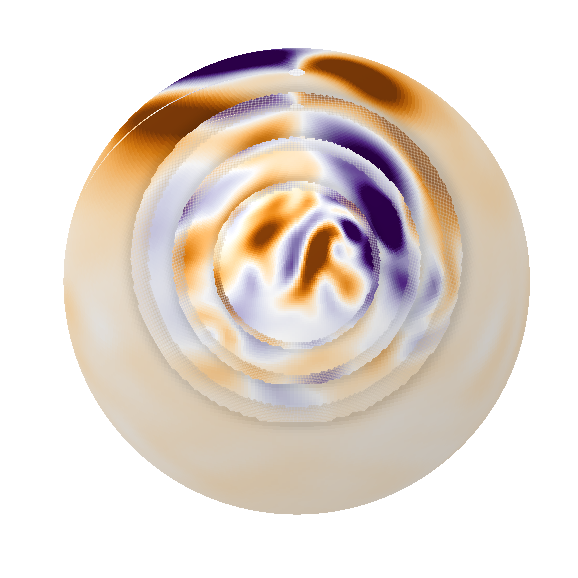

In [31]:
fig, ax = plot_layered_cutaway_globe(
    ds_with_ssw,
    var="vcomp",
    time_idx=3698,
    #time_idx=1000,
    elev=30,
    azim=90,
    figsize=(6, 6),
    dpi=120,
    lim=1.35,
    hole_x=0,
    hole_y=0.1,
    light_strength=0.1,
    rim_strength=0.12,
    rim_sigma=0.035,
    depth_darkening_per_layer=0.04,
    layers=[
        {"level": 900, "radius": 1.00, "alpha": 1.00, "hole_radius": 0.00},
        {"level": 500, "radius": 1.3, "alpha": 1.0, "hole_radius": 0.5},
        {"level": 100, "radius": 1.6, "alpha": 1.0, "hole_radius": 0.6},
        {"level":  10, "radius": 1.9, "alpha": 1.0, "hole_radius": 0.67},
    ],
    cmap_name="PuOr_r",)

In [32]:
fig.savefig("vcomp_900_500_100_10_with_ssw.png", transparent=True)

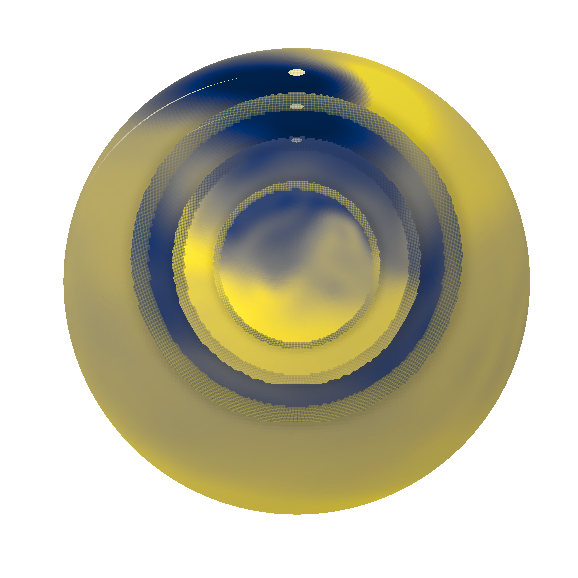

In [33]:
fig, ax = plot_layered_cutaway_globe(
    ds_with_ssw,
    var="temp",
    time_idx=3698,
    #time_idx=1000,
    elev=30,
    azim=90,
    figsize=(6, 6),
    dpi=120,
    lim=1.35,
    hole_x=0,
    hole_y=0.1,
    light_strength=0.1,
    rim_strength=0.12,
    rim_sigma=0.035,
    depth_darkening_per_layer=0.04,
    layers=[
        {"level": 900, "radius": 1.00, "alpha": 1.00, "hole_radius": 0.00},
        {"level": 500, "radius": 1.3, "alpha": 1.0, "hole_radius": 0.5},
        {"level": 100, "radius": 1.6, "alpha": 1.0, "hole_radius": 0.6},
        {"level":  10, "radius": 1.9, "alpha": 1.0, "hole_radius": 0.67},
    ],
    cmap_name="cividis",)

In [34]:
fig.savefig("temp_900_500_100_10_with_ssw.png", transparent=True)

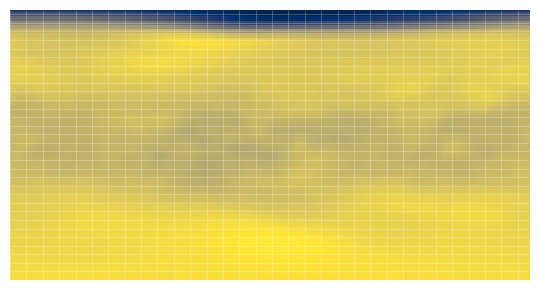

In [30]:
import numpy as np
import matplotlib.pyplot as plt

ds = ds_with_ssw
time_idx = 1000
level = 10

da = (
    ds["temp"]
    .isel(time=time_idx)
    .sel(pfull=level, method="nearest")
    .load()
)

T = da.values
lon = da["lon"].values
lat = da["lat"].values

lonb = ds["lonb"].values if "lonb" in ds.coords else None
latb = ds["latb"].values if "latb" in ds.coords else None

fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=100)

if lonb is not None and latb is not None:
    ax.pcolormesh(lonb, latb, T, cmap="cividis", shading="flat")
else:
    ax.pcolormesh(lon, lat, T, cmap="cividis", shading="auto")

grid_every_lon = 4
grid_every_lat = 2

for x in lon[::grid_every_lon]:
    ax.axvline(x, color="white", lw=0.5, alpha=0.35, zorder=3)

for y in lat[::grid_every_lat]:
    ax.axhline(y, color="white", lw=0.5, alpha=0.35, zorder=3)

ax.set_xlim(lon.min(), lon.max())
ax.set_ylim(lat.min(), lat.max())

# cleaner schematic-style look
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()
plt.savefig("rectangle_temp_10hpa.png", transparent=True, bbox_inches="tight", pad_inches=0.02)
plt.show()

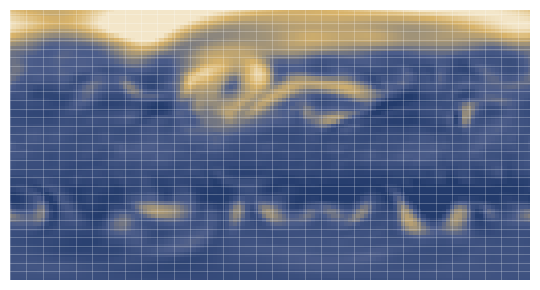

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from matplotlib.colors import LinearSegmentedColormap

# --- custom sequential cmap inspired by cividis + PuOr_r + coolwarm ---
cnn2d_summary_cmap = LinearSegmentedColormap.from_list(
    "cnn2d_summary",
    [
        "#233b6c",  # deep blue
        "#4c5d8a",  # muted blue-grey
        "#9a8f7a",  # warm neutral
        "#d8b36a",  # muted orange-gold
        "#f3e6c9",  # pale warm high end
    ],
    N=256,
)

ds = ds_with_ssw
time_idx = 1000

# choose which variables should define the CNN2D channel stack
vars_for_summary = ["temp", "ucomp", "vcomp"]

# stack variables into one array with dims: (var, pfull, lat, lon)
x = xr.concat(
    [ds[v].isel(time=time_idx).load() for v in vars_for_summary],
    dim="var"
).assign_coords(var=vars_for_summary)

# standardize each channel (each variable-pressure pair) over horizontal space
mu = x.mean(dim=("lat", "lon"))
sigma = x.std(dim=("lat", "lon"))
sigma = xr.where(sigma > 1e-6, sigma, 1e-6)

x_std = (x - mu) / sigma

# aggregated summary over all channels:
# RMS standardized magnitude across variables x pressure levels
summary = np.sqrt((x_std ** 2).mean(dim=("var", "pfull")))

S = summary.values
lon = summary["lon"].values
lat = summary["lat"].values

lonb = ds["lonb"].values if "lonb" in ds.coords else None
latb = ds["latb"].values if "latb" in ds.coords else None

# optional robust limits for better contrast
vmin = np.nanpercentile(S, 2)
vmax = np.nanpercentile(S, 98)

fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=100)

if lonb is not None and latb is not None:
    ax.pcolormesh(
        lonb, latb, S,
        cmap=cnn2d_summary_cmap,
        shading="flat",
        vmin=vmin,
        vmax=vmax,
    )
else:
    ax.pcolormesh(
        lon, lat, S,
        cmap=cnn2d_summary_cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

grid_every_lon = 4
grid_every_lat = 2

for xline in lon[::grid_every_lon]:
    ax.axvline(xline, color="white", lw=0.5, alpha=0.35, zorder=3)

for yline in lat[::grid_every_lat]:
    ax.axhline(yline, color="white", lw=0.5, alpha=0.35, zorder=3)

ax.set_xlim(lon.min(), lon.max())
ax.set_ylim(lat.min(), lat.max())

# cleaner schematic-style look
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()
plt.savefig("rectangle_channel_summary.png", transparent=True, bbox_inches="tight", pad_inches=0.02)
plt.show()

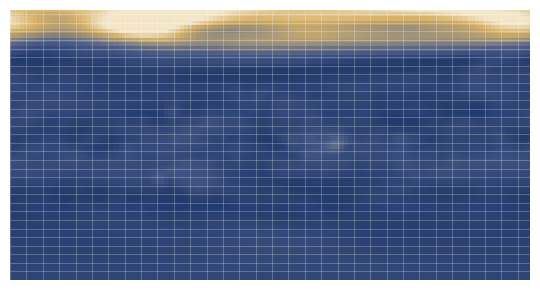

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap

# custom cmap for mixed-variable summary
cnn_summary_cmap = LinearSegmentedColormap.from_list(
    "cnn_summary",
    [
        "#233b6c",
        "#4c5d8a",
        "#9a8f7a",
        "#d8b36a",
        "#f3e6c9",
    ],
    N=256,
)

ds = ds_with_ssw
time_idx = 1000
level = 10  # choose pressure level here

vars_for_summary = ["temp", "ucomp", "vcomp"]

# stack variables at one selected pressure level
x = xr.concat(
    [
        ds[v]
        .isel(time=time_idx)
        .sel(pfull=level, method="nearest")
        .load()
        for v in vars_for_summary
    ],
    dim="var"
).assign_coords(var=vars_for_summary)

# standardize each variable over horizontal space
mu = x.mean(dim=("lat", "lon"))
sigma = x.std(dim=("lat", "lon"))
sigma = xr.where(sigma > 1e-6, sigma, 1e-6)

x_std = (x - mu) / sigma

# aggregate across variables only
summary = np.sqrt((x_std ** 2).mean(dim="var"))
# alternative:
# summary = np.abs(x_std).mean(dim="var")

S = summary.values
lon = summary["lon"].values
lat = summary["lat"].values

lonb = ds["lonb"].values if "lonb" in ds.coords else None
latb = ds["latb"].values if "latb" in ds.coords else None

vmin = np.nanpercentile(S, 2)
vmax = np.nanpercentile(S, 98)

fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=100)

if lonb is not None and latb is not None:
    ax.pcolormesh(
        lonb, latb, S,
        cmap=cnn_summary_cmap,
        shading="flat",
        vmin=vmin,
        vmax=vmax,
    )
else:
    ax.pcolormesh(
        lon, lat, S,
        cmap=cnn_summary_cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

grid_every_lon = 4
grid_every_lat = 2

for xline in lon[::grid_every_lon]:
    ax.axvline(xline, color="white", lw=0.5, alpha=0.35, zorder=3)

for yline in lat[::grid_every_lat]:
    ax.axhline(yline, color="white", lw=0.5, alpha=0.35, zorder=3)

ax.set_xlim(lon.min(), lon.max())
ax.set_ylim(lat.min(), lat.max())

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()
plt.savefig(f"rectangle_varmix_{level}hpa.png", transparent=True, bbox_inches="tight", pad_inches=0.02)
plt.show()

## OLD

In [ ]:
var = "temp"

for p_target in [1000, 950, 800, 1, 0.5, 0.01, 0.0001]:   # if your pfull is Pa, use 90000, 50000, 20000
    for time_idx in [0, 100, 1200]:
        # 2D slice: (lat, lon)$
        sl = ds[var].sel(pfull=p_target, method="nearest").isel(time=time_idx).compute()
        nan_mask = sl.isnull().values

        if int(nan_mask.sum()) > 0:
            print(f"Found {nan_mask.sum()} NaN values in {var} at time={sl['time'].values}, pfull={float(sl['pfull'].values):g}")

In [78]:
import numpy as np

var = "temp"
a = ds[var]

# 1) Global checks
print("Any NaN in temp:", bool(a.isnull().any().compute()))
print("Any non-finite (NaN/inf) in temp:", bool((~np.isfinite(a)).any().compute()))

# 2) Count NaNs per (time, pfull)
nan_tp = a.isnull().sum(dim=("lat", "lon")).compute()   # dims: time, pfull
print("Max NaNs in a (time,pfull) slice:", int(nan_tp.max()))
print("Number of bad (time,pfull) pairs:", int((nan_tp > 0).sum()))

# 3) First bad (time,pfull) pair
idx = np.argwhere((nan_tp > 0).values)
if idx.size:
    ti, pi = idx[0]
    print("First bad time_idx:", ti, "p_idx:", pi)
    print("time:", nan_tp["time"].values[ti], "pfull:", nan_tp["pfull"].values[pi])
    print("NaN count in that slice:", int(nan_tp.values[ti, pi]))
else:
    print("No NaNs found in temp.")


Any NaN in temp: True
Any non-finite (NaN/inf) in temp: True
Max NaNs in a (time,pfull) slice: 3
Number of bad (time,pfull) pairs: 9
First bad time_idx: 14394 p_idx: 59
time: 17314545.0 pfull: 900.0
NaN count in that slice: 1


In [79]:
for i in range(len(idx)):
    ti, pi = idx[i]
    print("time_idx:", ti, "p_idx:", pi)

time_idx: 14394 p_idx: 59
time_idx: 14395 p_idx: 59
time_idx: 14396 p_idx: 59
time_idx: 14397 p_idx: 59
time_idx: 14398 p_idx: 59
time_idx: 14399 p_idx: 59
time_idx: 14400 p_idx: 59
time_idx: 14401 p_idx: 59
time_idx: 14402 p_idx: 59


In [47]:
ti, pi

(np.int64(624), np.int64(59))

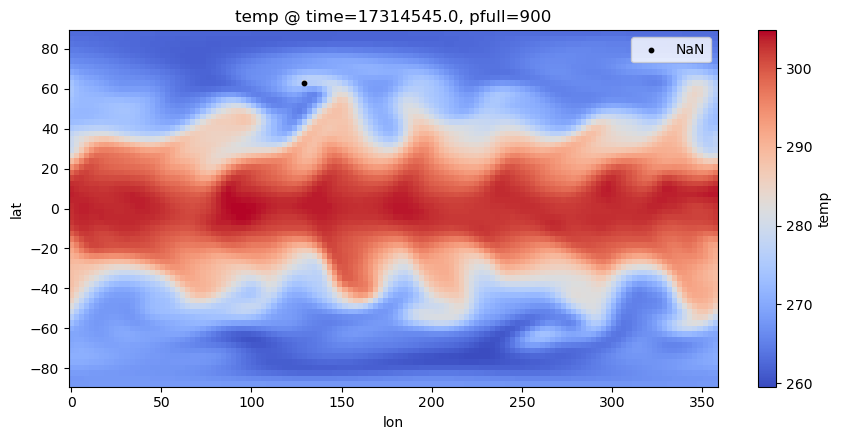

NaNs in this slice: 1


In [80]:
var = "temp"
p_target = 900   # if your pfull is Pa, use 90000
time_idx = 14394

# 2D slice: (lat, lon)
sl = ds[var].sel(pfull=p_target, method="nearest").isel(time=time_idx).compute()
nan_mask = sl.isnull().values

fig, ax = plt.subplots(figsize=(9, 4.5))

# Heatmap
cmap = plt.cm.coolwarm.copy()
cmap.set_bad("lightgray")  # background color where NaN
im = ax.pcolormesh(sl["lon"], sl["lat"], sl.values, shading="auto", cmap=cmap)

# NaN dots
iy, ix = np.where(nan_mask)
ax.scatter(sl["lon"].values[ix], sl["lat"].values[iy], s=10, c="black", label="NaN")

ax.set_title(f"{var} @ time={sl['time'].values}, pfull={float(sl['pfull'].values):g}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label=var)
plt.tight_layout()
plt.show()

print("NaNs in this slice:", int(nan_mask.sum()))


In [ ]:
# ucomp(time, pfull, lat, lon)
u = ds["ucomp"]

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_60N_p10 = (
    u.sel(pfull=10, lat=60, method="nearest")
     .mean(dim="lon",)
)[500:]

# Force data into memory, then convert to NumP
u_60N_p10_np = u_60N_p10.load().to_numpy()

# Optional: matching time axis as NumPy
time_np = u_60N_p10["time"].to_numpy()

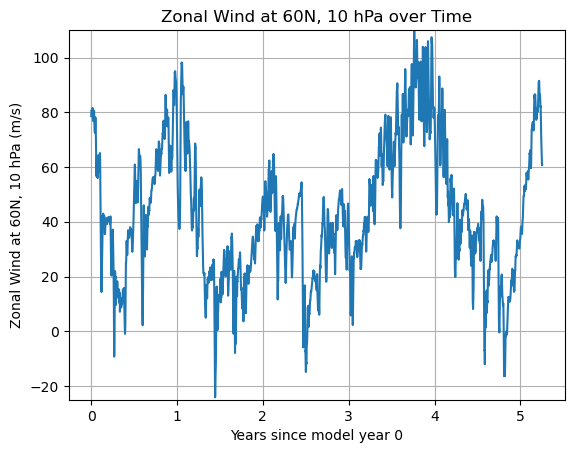

In [4]:
t0 = time_np[0]  # reference time (model year 0)
t_hours = time_np.astype(float)

years_since_0 = (t_hours - t0) / (24 * 365.0)
months_since_0 = (t_hours - t0) / (24 * 30.0)  # approx months

plt.plot(years_since_0, u_60N_p10_np)
plt.xlabel("Years since model year 0")
plt.ylabel("Zonal Wind at 60N, 10 hPa (m/s)")
plt.title("Zonal Wind at 60N, 10 hPa over Time")
plt.ylim(-25,110)
plt.grid(True)
plt.show()


In [5]:
path = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_no_ssw_L60"
file_name ="atmos_daily.nc"

ds_no_ssw = load_isca_result_data(path, file_name)

# ucomp(time, pfull, lat, lon)
u_no_ssw = ds_no_ssw["ucomp"]

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_no_ssw_60N_p10 = (
    u_no_ssw.sel(pfull=10, lat=60, method="nearest")
     .mean(dim="lon")
)[500:]

# Force data into memory, then convert to NumPy
u_no_ssw_60N_p10_np = u_no_ssw_60N_p10.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_no_ssw = u_no_ssw_60N_p10["time"].to_numpy()

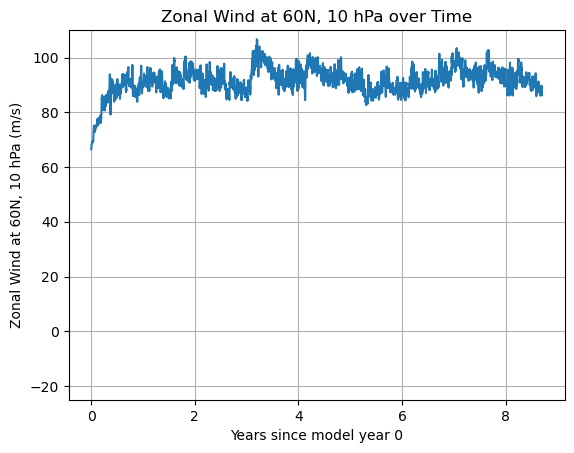

In [ ]:
vars_cfg = ["temp", "ucomp", "vcomp"]
times = ds_no_ssw['time'].values
pvals = ds_no_ssw['pfull'].values.astype(float)

ds_preview = ds_no_ssw.isel(
    time=slice(500, 2000),      
    pfull=slice(None, None, 1),
    lat=slice(None, None, 1),
    lon=slice(None, None, 1))

times_preview = ds_preview["time"].values
pvals_preview = ds_preview["pfull"].values.astype(float)

plot_isca_result(ds_preview, times_preview, pvals_preview, vars_cfg)

/home/obola/repositories/isca_emulation_v2/src/isca_emulation_v2/plotting/plotting_functions.py:124: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension()


Launching server at http://127.0.0.1:35083


ERROR:tornado.application:Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7252b56809d0>>, <Task finished name='Task-1937' coro=<ServerSession.with_document_locked() done, defined at /home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py:77> exception=RuntimeError("Models must be owned by only a single document, ImportedStyleSheet(id='7aa4781e-4090-442f-8f99-ee3927824ce5', ...) is already in a doc")>)
Traceback (most recent call last):
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 774, in _discard_future_result
    future.result()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py", line 94, in _needs_document_lock_wrapper
    result = func(self, *a

2026-03-10 22:41:59,715 ERROR: panel.reactive - Callback failed for object named 'time index' changing property {'value_throttled': 123} 
Traceback (most recent call last):
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/panel/reactive.py", line 470, in _process_events
    self.param.update(**self_params)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2788, in update
    restore = dict(self_._update(arg, **kwargs))
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2821, in _update
    self_._batch_call_watchers()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3038, in _batch_call_watchers
    self_._execute_watcher(watcher, events)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3000, in _execute_watcher
    watcher

ERROR:tornado.application:Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7252b56809d0>>, <Task finished name='Task-17695' coro=<ServerSession.with_document_locked() done, defined at /home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py:77> exception=RuntimeError("Models must be owned by only a single document, ImportedStyleSheet(id='7aa4781e-4090-442f-8f99-ee3927824ce5', ...) is already in a doc")>)
Traceback (most recent call last):
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 774, in _discard_future_result
    future.result()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py", line 98, in _needs_document_lock_wrapper
    result = await result

2026-03-10 22:42:16,249 ERROR: panel.reactive - Callback failed for object named 'time index' changing property {'value_throttled': 134} 
Traceback (most recent call last):
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/panel/reactive.py", line 470, in _process_events
    self.param.update(**self_params)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2788, in update
    restore = dict(self_._update(arg, **kwargs))
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2821, in _update
    self_._batch_call_watchers()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3038, in _batch_call_watchers
    self_._execute_watcher(watcher, events)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3000, in _execute_watcher
    watcher

ERROR:tornado.application:Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7252b56809d0>>, <Task finished name='Task-18968' coro=<ServerSession.with_document_locked() done, defined at /home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py:77> exception=RuntimeError("Models must be owned by only a single document, ImportedStyleSheet(id='7aa4781e-4090-442f-8f99-ee3927824ce5', ...) is already in a doc")>)
Traceback (most recent call last):
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 774, in _discard_future_result
    future.result()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py", line 98, in _needs_document_lock_wrapper
    result = await result

2026-03-10 22:42:21,764 ERROR: panel.reactive - Callback failed for object named 'time index' changing property {'value_throttled': 137} 
Traceback (most recent call last):
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/panel/reactive.py", line 470, in _process_events
    self.param.update(**self_params)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2788, in update
    restore = dict(self_._update(arg, **kwargs))
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 2821, in _update
    self_._batch_call_watchers()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3038, in _batch_call_watchers
    self_._execute_watcher(watcher, events)
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/param/parameterized.py", line 3000, in _execute_watcher
    watcher

ERROR:tornado.application:Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7252b56809d0>>, <Task finished name='Task-19376' coro=<ServerSession.with_document_locked() done, defined at /home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py:77> exception=RuntimeError("Models must be owned by only a single document, ImportedStyleSheet(id='7aa4781e-4090-442f-8f99-ee3927824ce5', ...) is already in a doc")>)
Traceback (most recent call last):
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
  File "/home/obola/.local/lib/python3.10/site-packages/tornado/ioloop.py", line 774, in _discard_future_result
    future.result()
  File "/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/bokeh/server/session.py", line 98, in _needs_document_lock_wrapper
    result = await result

In [ ]:
train_mean_temp = ds['temp'][500:2100,:,:,:].mean(dim=('time', 'lat', 'lon')).values
train_std_temp = ds['temp'][500:2100,:,:,:].std(dim=('time', 'lat', 'lon')).values

In [ ]:
train_mean_temp

array([180.12296, 190.7099 , 190.43445, 193.51125, 195.58351, 199.68262,
       204.75047, 210.82765, 217.84535, 224.97466, 231.28273, 236.34383,
       241.1568 , 245.51862, 249.15317, 251.22969, 252.14067, 251.64996,
       249.73007, 246.67957, 243.83606, 240.8586 , 238.01459, 235.06578,
       232.32896, 229.7648 , 227.36035, 225.1501 , 223.19156, 222.22446,
       221.68742, 221.3125 , 221.03433, 220.82133, 220.66164, 220.53043,
       220.35852, 220.16852, 219.98691, 220.08649, 220.71252, 221.5312 ,
       222.5661 , 223.55128, 224.97998, 226.54562, 228.14542, 230.22704,
       232.76555, 235.83391, 239.64285, 243.75372, 248.43208, 253.25389,
       258.55005, 263.69952, 269.2551 , 274.27206, 279.2942 , 281.89905],
      dtype=float32)

In [ ]:
train_std_temp

array([ 4.686314 ,  3.4555528,  4.682161 ,  6.9942226, 10.070696 ,
       12.059491 , 13.907135 , 15.031691 , 16.387766 , 16.763308 ,
       16.537956 , 15.93087  , 14.814869 , 13.205879 , 11.292632 ,
       10.482579 , 10.891477 , 12.754618 , 15.388376 , 17.222635 ,
       18.434336 , 19.242813 , 19.322126 , 19.10522  , 18.446993 ,
       17.723297 , 16.605131 , 15.347383 , 13.88795  , 12.639839 ,
       11.615842 , 10.661554 ,  9.75128  ,  8.899263 ,  8.16417  ,
        7.5949464,  7.2977624,  7.3507237,  7.5295296,  7.4346933,
        7.2225537,  7.1157804,  7.85083  ,  8.481869 ,  9.000279 ,
        8.975024 ,  8.242615 ,  7.782768 ,  7.6665893,  7.8194275,
        8.30698  ,  9.0756445,  9.974824 , 10.915579 , 11.735316 ,
       12.502993 , 13.219909 , 13.969986 , 14.411674 , 14.49126  ],
      dtype=float32)

In [ ]:
ds['temp'][2300:2500,:,:,:].mean(dim=('time', 'lat', 'lon')).values

array([178.44464, 189.3853 , 188.82329, 192.07025, 194.20885, 198.48746,
       203.41801, 209.77211, 217.21918, 224.74266, 231.10458, 236.22566,
       241.14078, 245.58058, 249.42175, 251.55237, 252.11496, 252.33574,
       250.4251 , 246.89273, 242.20395, 238.23851, 234.97536, 232.06949,
       229.67027, 227.51402, 225.40376, 223.24133, 221.24957, 220.46797,
       219.95207, 219.65855, 219.37505, 219.15753, 218.95406, 218.69992,
       218.4742 , 218.28299, 218.14397, 218.1855 , 218.73805, 219.40285,
       220.4071 , 221.33824, 222.90948, 224.68903, 226.43045, 228.5107 ,
       231.17566, 234.46164, 238.54512, 242.92265, 247.78922, 252.75923,
       258.116  , 263.34595, 268.90164, 273.9911 , 279.01666, 281.61496],
      dtype=float32)

In [ ]:
print(list(ds.var()))

['height', 'slp', 'ps', 'sphum', 'zsurf', 'ucomp', 'vcomp', 'omega', 'temp', 'teq', 'local_heating']


In [ ]:
ds

<xarray.Dataset> Size: 399GB
Dimensions:        (time: 25200, pfull: 60, lat: 64, lon: 128, lonb: 129,
                    latb: 65)
Coordinates:
  * lon            (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * lonb           (lonb) float64 1kB -1.406 1.406 4.219 ... 353.0 355.8 358.6
  * lat            (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * latb           (latb) float64 520B -90.0 -86.58 -83.76 ... 83.76 86.58 90.0
  * pfull          (pfull) float32 240B 0.02 0.04 0.05 ... 795.4 872.0 955.8
  * time           (time) float64 202kB 1.727e+07 1.727e+07 ... 1.735e+07
Data variables:
    height         (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    slp            (time, lat, lon) float32 826MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    ps             (time, lat, lon) float32 826MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    sphum          (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    zsurf          (time, lat, lon) float32 826MB dask.array<chunksize=(240, 64, 128), meta=np.ndarray>
    ucomp          (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    vcomp          (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    omega          (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    temp           (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    teq            (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
    local_heating  (time, pfull, lat, lon) float32 50GB dask.array<chunksize=(240, 60, 64, 128), meta=np.ndarray>
Attributes:
    filename:   /home/obola/isca_data//Oskar_data_generation_large_run_q6m2y4...
    title:      FMS Model results
    grid_type:  regular
    grid_tile:  N/A
    comment:    pressure level interpolator, version 3.0, precision=double

In [ ]:
ds['temp']

<xarray.DataArray 'temp' (time: 25200, pfull: 60, lat: 64, lon: 128)> Size: 50GB
dask.array<concatenate, shape=(25200, 60, 64, 128), dtype=float32, chunksize=(240, 60, 64, 128), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * pfull    (pfull) float32 240B 0.02 0.04 0.05 0.08 ... 795.4 872.0 955.8
  * time     (time) float64 202kB 1.727e+07 1.727e+07 ... 1.735e+07 1.735e+07
Attributes:
    long_name:     temperature
    units:         deg_k
    valid_range:   [ 50. 800.]
    cell_methods:  time: point

In [ ]:
vars_cfg = ["temp", "ucomp", "vcomp"]
times = ds['time'].values
pvals = ds['pfull'].values.astype(float)

ds_preview = ds.isel(
    time=slice(500, 2000),      
    pfull=slice(None, None, 1),
    lat=slice(None, None, 1),
    lon=slice(None, None, 1),
)

times_preview = ds_preview["time"].values
pvals_preview = ds_preview["pfull"].values.astype(float)

plot_isca_result(ds_preview, times_preview, pvals_preview, vars_cfg)

/home/obola/repositories/isca_emulation_v2/src/isca_emulation_v2/plotting/plotting_functions.py:124: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension()


Launching server at http://127.0.0.1:42511
